# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [84]:
ПІБ = 'Костак Олеся'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 6    # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [85]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 6 · Костак Олеся, ШІ-32, «Longer Boats»
Підприємство «Longer Boats» виготовляє яхти. Одиниця виміру плану: шт./місяць.

                       Sting  Ray  Breaker  Marlin  ЗАПАС
Склопластик, м²            3    2        1       4    630
Столярний цех, год         4    2        2       1    391
Фарбувальний цех, год      3    5        1       2   1349
Такелаж, компл.            3    2        0       2    811
Ділянка добудови, год      6    4        6       3   1085

                    Sting  Ray  Breaker  Marlin
Прибуток з одиниці     40   62       19      57

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   29.5 за одиницю
  обсяг:  до 268 одиниць


In [86]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x_1 - sting, x_2 - ray, x_3 - breaker, x_4 - marlin

Цільова функція: 40x_1 + 62x_2 + 19x_3 + 57x_4 → max

Обмеження: 
3x_1 + 2x_2 + 1x_3 + 4x_4 ≤ 630   
4x_1 + 2x_2 + 2x_3 + 1x_4 ≤ 391   
3x_1 + 5x_2 + 1x_3 + 2x_4 ≤ 1349 
3x_1 + 2x_2 + 0x_3 + 2x_4 ≤ 811   
6x_1 + 4x_2 + 6x_3 + 3x_4 ≤ 1085  

Невід'ємність:
x_1, x_2, x_3, x_4 >= 0

### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** тому що основна задача - пошук таких значень змінних, при заданих обмеженнях, при яких б цільова функція досягала свого максимуму. Окрім того запаси ресурсів визначаються до етапу з пошуком розв'язку, тому це параметр. 

Якщо припустити, що підприємство могло б докупити ресурс у будь-якій кількості, то ця задача б просто містила більше змінних у цільовій функції, а також обмеження мали б інший вигляд (старий запас + докуплена кількість).

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [87]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [0, 155.67, 0, 79.67]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 14192.33             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [0, 155.67, 0, 79.67] | прибуток 14192.33


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [88]:
from scipy.optimize import linprog
import numpy as np

In [89]:
# ВАШ КОД
c = np.array([40, 62, 19, 57], float)
A = np.array([
    [3, 2, 1, 4],
    [4, 2, 2, 1],
    [3, 5, 1, 2],
    [3, 2, 0, 2],
    [6, 4, 6, 3]
], float)
b = np.array([630, 391, 1349, 811, 1085], float)

res = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')

if res.success:
    план = list(res.x)
    базовий_прибуток = -res.fun
    print("Оптимальний план випуску (Python):",f"\n{план}")
    print("Максимальний прибуток (Python):", базовий_прибуток)
else:
    print("Поשлка розв'язання:", res.message)

Оптимальний план випуску (Python): 
[np.float64(0.0), np.float64(155.66666666666666), np.float64(0.0), np.float64(79.66666666666669)]
Максимальний прибуток (Python): 14192.333333333332


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [90]:
прибуток = базовий_прибуток

In [91]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(базовий_прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, базовий_прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
|Склопластик  |630  |8,67  |630  |670  |239  |
|Столярний цех |391  |22,33  |391  |134  |233,5  |
|Фарбувальний цех  |937,67  |0  |1349  |1E+30  |411,33  |
|Такелаж  |470,67  |0  |811  |1E+30  |340,33  |
|Ділянка добудови  |861,67  |0  |1085  |1E+30  |223,33  |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**


В надлишку: фарбувальний цех, такелаж, ділянка добудови. У дефіциті: склопластик, столярний цех. У дефіциті усі ресурси, у яких кінцеве значення дорівнює правій частині, оскільки це означає, що усі запаси використані, у надлишкових вони частково використані.

### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|---|---|---|---|---|---|
|Sting    | 0 | -75,33 | 40 | 75,33 | 1E+30 |
|Ray    | 155,67 | 0 | 62 | 52 | 29,43 |
|Breaker    | 0 | -34,33 | 19 | 34,33 | 1E+30 |
|Marlin    | 79,67 | 0 | 57 | 67 | 26 |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?

Вироби які не виробляються: sting, breaker. Колонка із зведеною вартісю показує, на скільки мусив би зрости прибуток з одиниці виробу, щоб він увійшов у план. Дляф sting це 75.33, для breaker 34.33

---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [92]:
# ВАШ КОД
A_виробнича = np.asarray(V['A'], dtype=float)
c_виробнича = np.asarray(V['c'], dtype=float)
b_виробничий = np.asarray(V['b'], dtype=float)

res_базовий = linprog(
    -c_виробнича, A_ub=A_виробнича, b_ub=b_виробничий,
    bounds=(0, None), method='highs'
 )

if res_базовий.success:
    тіньові_ціни_виробничі = -res_базовий.ineqlin.marginals
    індекс_ресурсу = int(np.argmax(тіньові_ціни_виробничі))
    b_експериментальний = b_виробничий.copy()
    b_експериментальний[індекс_ресурсу] += 1

    res_експеримент = linprog(
        -c_виробнича, A_ub=A_виробнича, b_ub=b_експериментальний,
        bounds=(0, None), method='highs'
    )

    if res_експеримент.success:
        план_експерименту = list(res_експеримент.x)
        прибуток_експерименту = -res_експеримент.fun
        приріст_експерименту = прибуток_експерименту + res_базовий.fun
        print('Ресурс:', V['ресурси'][індекс_ресурсу])
        print('Базовий прибуток:', -res_базовий.fun)
        print('Прибуток після збільшення запасу на 1:', прибуток_експерименту)
        print('Приріст прибутку:', приріст_експерименту)
        print('Тіньова ціна зі звіту Python:', тіньові_ціни_виробничі[індекс_ресурсу])
        print('Оптимальний план у сценарії:', план_експерименту)
    else:
        print('Помилка сценарного розв’язання:', res_експеримент.message)
else:
    print('Помилка базового розв’язання:', res_базовий.message)

Ресурс: Столярний цех, год
Базовий прибуток: 14192.333333333332
Прибуток після збільшення запасу на 1: 14214.666666666668
Приріст прибутку: 22.33333333333576
Тіньова ціна зі звіту Python: 22.333333333333336
Оптимальний план у сценарії: [np.float64(0.0), np.float64(156.33333333333334), np.float64(0.0), np.float64(79.33333333333331)]


**Відповідь 5.1:** 

Базовий прибуток: 14192.33

Прибуток після збільшення запасу на 1: 14214.67

Приріст прибутку: 22.34

Тіньова ціна зі звіту Excel для Фанери: 22.33

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

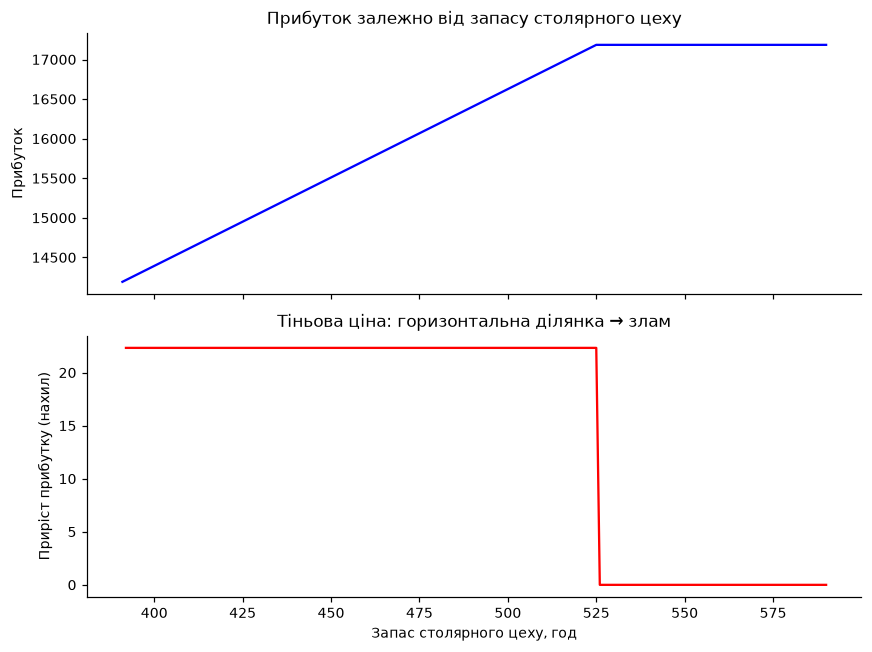

In [93]:
b_base = np.array([630, 391, 1349, 811, 1085], float)
b = b_base.copy()

приріст_запасу = np.arange(0, 200)
запаси = b_base[1] + приріст_запасу
прибутки = []

for b1 in запаси:
    b_scenario = b_base.copy()
    b_scenario[1] = b1
    res = linprog(-c, A_ub=A, b_ub=b_scenario, bounds=(0, None), method='highs')
    прибутки.append(-res.fun)

прибутки = np.array(прибутки)
приріст_прибутку = np.diff(прибутки)

fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax[0].plot(запаси, прибутки, color='blue')
ax[0].set_ylabel('Прибуток')
ax[0].set_title('Прибуток залежно від запасу столярного цеху')

ax[1].plot(запаси[1:], приріст_прибутку, color='red')
ax[1].set_xlabel('Запас столярного цеху, год')
ax[1].set_ylabel('Приріст прибутку (нахил)')
ax[1].set_title('Тіньова ціна: горизонтальна ділянка → злам')

fig.tight_layout()
plt.show()

**Відповідь 5.2:** 
запас можна збільшити на 525-391=134 одиниці. Дане значення збігається із тим, що у звіті. На верхньому графіку прибуток зростає лінійно, а на нижньому приріст тримається на стабільному рівні тіньової ціни до межі допустимого збільшення.

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Столярний цех, год
  ціна:   29.5 за одиницю
  обсяг:  до 268 одиниць

In [94]:
# ВАШ КОД
обсяг_купівлі = 0
ціна_постачальника = 29.5

b_test = b.copy()
b_test[1] += обсяг_купівлі

res_shop = linprog(-c, A_ub=A, b_ub=b_test, bounds=(0, None), method='highs')
новий_прибуток = -res_shop.fun
витрати_на_купівлю = обсяг_купівлі * ціна_постачальника
чистий_ефект = новий_прибуток - базовий_прибуток - витрати_на_купівлю

print(f"Базовий прибуток: {базовий_прибуток:.2f}")
print(f"Прибуток з урахуванням закупівлі: {новий_прибуток:.2f}")
print(f"Витрати на закупівлю: {витрати_на_купівлю:.2f}")
print(f"Чистий ефект від закупівлі: {чистий_ефект:.2f}")

Базовий прибуток: 14192.33
Прибуток з урахуванням закупівлі: 14192.33
Витрати на закупівлю: 0.00
Чистий ефект від закупівлі: 0.00


**Відповідь 6.1:**

* Брати чи ні і чому: Не брати, оскільки тіньова ціна столярного цеху 22.33, а постачальник пропонує взяти за 29.5. Таким чином ми вийдемо лише в мінус.
* Скільки одиниць має сенс купити і чому не більше: 0 одиниць, оскільки закупівля є збитковою.
* Очікуваний виграш: 0
* Перевірка прямим розв'язанням дала: підтвердження відсутності приросту прибутку за такої ціни.


---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [95]:
# ВАШ КОД
res_base = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs')
план = list(res_base.x)
eps = 1e-6

ненульових = sum(1 for x in план if x > eps)

витрачено = A @ np.array(план)
звязних = sum(1 for витр, запас_i in zip(витрачено, b) if abs(витр - запас_i) < eps)

print('ненульових змінних:', ненульових)
print('зв’язних обмежень:', звязних)


ненульових змінних: 2
зв’язних обмежень: 2


In [96]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)*

Так, числа збіглися: 2 ненульові змінні (Ray і Marlin) і 2 зв'язні обмеження
(Склопластик і Столярний цех). Для базисного оптимального розв’язку кількість позитивних змінних зазвичай дорівнює кількості активних обмежень. Якщо б ці числа не збіглися, це було б сигналом про помилку у розв’язанні або про виродженість/альтернативний оптимум.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [97]:
# ВАШ КОД
план_неперервний = план
витрачено_неперервний = A @ np.array(план_неперервний)
прибуток_неперервний = c @ np.array(план_неперервний)
допустимий_неперервний = np.all(витрачено_неперервний <= b + eps)

print('1. НЕПЕРЕРВНИЙ ПЛАН')
print('   план:', план_неперервний)
print('   витрачено:', витрачено_неперервний)
print('   прибуток:', прибуток_неперервний)
print('   допустимий:', допустимий_неперервний)
print()

план_округлений = np.round(план_неперервний)
витрачено_округлений = A @ план_округлений
прибуток_округлений = c @ план_округлений
допустимий_округлений = np.all(витрачено_округлений <= b + eps)

print('2. ОКРУГЛЕНИЙ ПЛАН')
print('   план:', план_округлений)
print('   витрачено:', витрачено_округлений)
print('   запаси:   ', b)
print('   прибуток:', прибуток_округлений)
print('   допустимий:', допустимий_округлений)
print()

res_int = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method='highs', integrality=1)
план_цілий = res_int.x
витрачено_цілий = A @ план_цілий
прибуток_цілий = -res_int.fun
допустимий_цілий = np.all(витрачено_цілий <= b + eps)

print('3. ЦІЛОЧИСЕЛЬНИЙ ОПТИМУМ')
print('   план:', план_цілий)
print('   витрачено:', витрачено_цілий)
print('   прибуток:', прибуток_цілий)
print('   допустимий:', допустимий_цілий)

1. НЕПЕРЕРВНИЙ ПЛАН
   план: [np.float64(0.0), np.float64(155.66666666666666), np.float64(0.0), np.float64(79.66666666666669)]
   витрачено: [630.         391.         937.66666667 470.66666667 861.66666667]
   прибуток: 14192.333333333332
   допустимий: True

2. ОКРУГЛЕНИЙ ПЛАН
   план: [  0. 156.   0.  80.]
   витрачено: [632. 392. 940. 472. 864.]
   запаси:    [ 630.  391. 1349.  811. 1085.]
   прибуток: 14232.0
   допустимий: False

3. ЦІЛОЧИСЕЛЬНИЙ ОПТИМУМ
   план: [  0. 156.   0.  79.]
   витрачено: [628. 391. 938. 470. 861.]
   прибуток: 14175.0
   допустимий: True


**Відповідь 8.1:**

| Варіант | План | Прибуток | Допустимий? |
|---|---|---|---|
| без умови цілочисельності | [0, 155.67, 0, 79.67] | 14192.33 | Так |
| округлений | [  0, 156,  0,  80] | 14232.0 | Ні |
| цілочисельний оптимум | [  0, 156,   0,  79] | 14175.0 | Так |

**Висновок:** *(чи можна округлювати і чому)*


Округлення застосовувати самостійно не варто, оскільки таким чином можна вийти за межі наявних ресурсів. Тому справжній оптимум треба знаходити з умовою цілочисельності. Але при цьому прибуток становить 14175, що менше, ніж у дробовому розв’язку, але план є допустимим і фізично реалізовним.

---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [98]:
# ВАШ КОД — впишіть свої дані
постачальники = ['Київ', 'Одеса', 'Суми']            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ['Олевськ', 'Луцьк', 'Енергодар', 'Сімферополь']            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
    [238, 406, 728, 1059],
    [693, 818, 623, 954],
    [565, 739, 607, 938]
], dtype=float)              # матриця відстаней 3 x 4, км
запас = np.array([50, 40, 30], dtype=float)           # Київ, Одеса, Суми — разом 120
попит = np.array([25, 35, 20, 40], dtype=float)       # Олевськ, Луцьк, Енергодар, Сімферополь — разом 120

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Олевськ,Луцьк,Енергодар,Сімферополь
Київ,238.0,406.0,728.0,1059.0
Одеса,693.0,818.0,623.0,954.0
Суми,565.0,739.0,607.0,938.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [99]:
# ВАШ КОД — розв'язок 1
n_s, n_c = 3, 4
c = D.flatten()

A_eq, b_eq = [], []
for i in range(n_s):
    row = np.zeros(n_s * n_c)
    row[i*n_c:(i+1)*n_c] = 1
    A_eq.append(row); b_eq.append(запас[i])
for j in range(n_c):
    row = np.zeros(n_s * n_c)
    for i in range(n_s):
        row[i*n_c + j] = 1
    A_eq.append(row); b_eq.append(попит[j])

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=(0, None), method='highs')
X_scipy = res.x.reshape(n_s, n_c)

print('План (SciPy):\n', pd.DataFrame(X_scipy, index=постачальники, columns=споживачі))
print('Вартість:', res.fun)
print('Тіньові ціни, постачальники:', dict(zip(постачальники, res.eqlin.marginals[:n_s])))
print('Тіньові ціни, споживачі:    ', dict(zip(споживачі, res.eqlin.marginals[n_s:])))

План (SciPy):
        Олевськ  Луцьк  Енергодар  Сімферополь
Київ      15.0   35.0        0.0          0.0
Одеса      0.0    0.0        0.0         40.0
Суми      10.0    0.0       20.0         -0.0
Вартість: 73730.0
Тіньові ціни, постачальники: {'Київ': np.float64(280.0), 'Одеса': np.float64(623.0), 'Суми': np.float64(607.0)}
Тіньові ціни, споживачі:     {'Олевськ': np.float64(-42.0), 'Луцьк': np.float64(126.0), 'Енергодар': np.float64(-0.0), 'Сімферополь': np.float64(331.0)}


In [100]:
# ВАШ КОД — розв'язок 2
import pulp

prob = pulp.LpProblem('transport', pulp.LpMinimize)
x = [[pulp.LpVariable(f'x_{i}_{j}', lowBound=0) for j in range(n_c)] for i in range(n_s)]
prob += pulp.lpSum(D[i][j] * x[i][j] for i in range(n_s) for j in range(n_c))

supply_con = []
for i in range(n_s):
    name = f'supply_{i}'
    prob += pulp.lpSum(x[i][j] for j in range(n_c)) == запас[i], name
    supply_con.append(prob.constraints[name])

demand_con = []
for j in range(n_c):
    name = f'demand_{j}'
    prob += pulp.lpSum(x[i][j] for i in range(n_s)) == попит[j], name
    demand_con.append(prob.constraints[name])

prob.solve(pulp.COIN_CMD(path=r"C:\Users\Admin\anaconda3\envs\study\Library\bin\cbc.exe", msg=0))

X_pulp = np.array([[x[i][j].value() for j in range(n_c)] for i in range(n_s)])
print('План (PuLP):\n', pd.DataFrame(X_pulp, index=постачальники, columns=споживачі))
print('Вартість:', pulp.value(prob.objective))
print('Тіньові ціни, постачальники:', {постачальники[i]: supply_con[i].pi for i in range(n_s)})
print('Тіньові ціни, споживачі:    ', {споживачі[j]: demand_con[j].pi for j in range(n_c)})

План (PuLP):
        Олевськ  Луцьк  Енергодар  Сімферополь
Київ      15.0   35.0        0.0          0.0
Одеса      0.0    0.0       20.0         20.0
Суми      10.0    0.0        0.0         20.0
Вартість: 73730.0
Тіньові ціни, постачальники: {'Київ': 238.0, 'Одеса': 581.0, 'Суми': 565.0}
Тіньові ціни, споживачі:     {'Олевськ': 0.0, 'Луцьк': 168.0, 'Енергодар': 42.0, 'Сімферополь': 373.0}


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [101]:
# ВАШ КОД — порівняння
ціни_scipy = dict(zip(
    постачальники + споживачі, res.eqlin.marginals.tolist()
))
ціни_pulp = dict(zip(
    постачальники + споживачі,
    [обмеження.pi for обмеження in supply_con + demand_con],
))

print('Вартість scipy:', res.fun)
print('Вартість PuLP:', pulp.value(prob.objective))
print('Тіньові ціни scipy:', ціни_scipy)
print('Тіньові ціни PuLP:', ціни_pulp)

Вартість scipy: 73730.0
Вартість PuLP: 73730.0
Тіньові ціни scipy: {'Київ': 280.0, 'Одеса': 623.0, 'Суми': 607.0, 'Олевськ': -42.0, 'Луцьк': 126.0, 'Енергодар': -0.0, 'Сімферополь': 331.0}
Тіньові ціни PuLP: {'Київ': 238.0, 'Одеса': 581.0, 'Суми': 565.0, 'Олевськ': 0.0, 'Луцьк': 168.0, 'Енергодар': 42.0, 'Сімферополь': 373.0}


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: однакова - 73730.0
* Тіньові ціни збіглися чи ні: ні, не збіглися. Наприклад, для Києва SciPy дав 280, а PuLP - 238;
  для Одеси - 623 проти 581.
* Яку закономірність ви побачили в різниці: для всіх трьох постачальників PuLP дає значення
  рівно на 42 менше, ніж SciPy. Стала різниця в один і той самий бік
  для кожної групи означає, що задача збалансована (сумарний запас
  = сумарному попиту)
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: абсолютне значення
  окремої тіньової ціни в транспортній задачі саме по собі не має економічного сенсу, оскільки
  залежить від випадкового вибору точки відліку конкретного розв'язувача, а не від структури
  самої задачі. Для ухвалення рішень слід опиратись на оптимальний план перевезень і відносні оцінки ефективності маршрутів.
 

---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [102]:
# ВАШ КОД
план_перевезень = X_pulp

non_zero_transports = int(np.sum(план_перевезень > eps))

запас_викор = план_перевезень.sum(axis=1)
попит_викор = план_перевезень.sum(axis=0)

звязних_постачальники = int(np.sum(np.abs(запас_викор - запас) < eps))
звязних_споживачі = int(np.sum(np.abs(попит_викор - попит) < eps))
звязних_разом = звязних_постачальники + звязних_споживачі

print(f"Кількість ненульових перевезень: {non_zero_transports}")
print(f"Кількість зв'язних обмежень (з {n_s + n_c}): {звязних_разом}")

Кількість ненульових перевезень: 6
Кількість зв'язних обмежень (з 7): 7


**Відповідь 11.1:**

* Ненульових перевезень: 6.
* Зв'язаних обмежень: 7 з 7.
* Усі обмеження зв'язані, бо це обмеження-рівності: кожен постачальник відвантажує весь запас, а кожен споживач отримує весь попит.
* Ненульових перевезень на одне менше, ніж обмежень. Одна з 7 рівностей лінійно залежна від решти, оскільки сумарний запас дорівнює сумарному попиту. Тому ранг системи дорівнює $3 + 4 - 1 = 6$, і базисний план має 6 позитивних маршрутів. Через цю залежність правило з етапу 7 тут напряму не працює.

### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

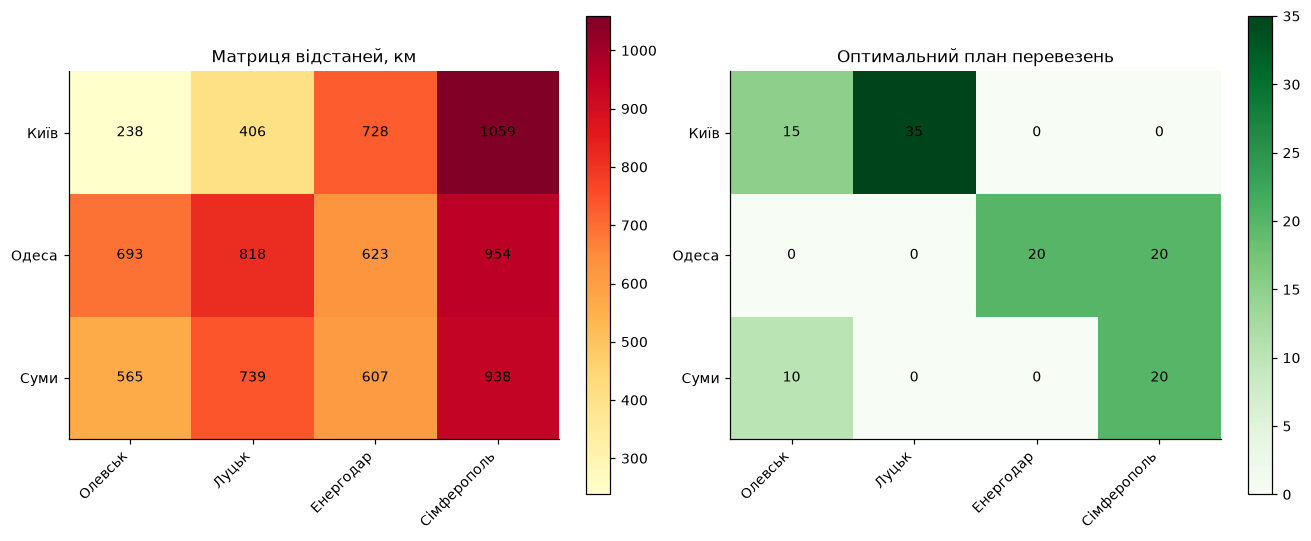

In [103]:
# ВАШ КОД
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(D, cmap='YlOrRd')
axes[0].set_xticks(range(len(споживачі)))
axes[0].set_xticklabels(споживачі, rotation=45, ha='right')
axes[0].set_yticks(range(len(постачальники)))
axes[0].set_yticklabels(постачальники)
axes[0].set_title('Матриця відстаней, км')
for i in range(D.shape[0]):
    for j in range(D.shape[1]):
        axes[0].text(j, i, f'{D[i, j]:.0f}', ha='center', va='center')
fig.colorbar(im0, ax=axes[0], fraction=0.046)


im1 = axes[1].imshow(X_pulp, cmap="Greens")
axes[1].set_xticks(range(len(споживачі)))
axes[1].set_xticklabels(споживачі, rotation=45, ha='right')
axes[1].set_yticks(range(len(постачальники)))
axes[1].set_yticklabels(постачальники)
axes[1].set_title('Оптимальний план перевезень')
for i in range(X_pulp.shape[0]):
    for j in range(X_pulp.shape[1]):
        axes[1].text(j, i, f'{X_pulp[i, j]:.0f}', ha='center', va='center')
fig.colorbar(im1, ax=axes[1], fraction=0.046)

fig.tight_layout()
plt.show()

**Висновок:** *(одне речення про те, що видно на теплових картах)*
Можна зробити висновок з теплових карт, що оптимальний план перевезень спрямовує основні обсяги вантажів на ті маршрути, де відстані є найменшими, а обсяги перевезень найбільшими. 

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [104]:
ІНСТРУМЕНТИ_ШІ = 'Claude'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'синтаксис',
    'етап 3, код на Python':                'синтаксис',
    'етапи 4–5, читання та перевірка звіту': 'синтаксис',
    'етап 6, рішення про закупівлю':        'ні',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = "згенеровано і перевірено код для розв'язку транспортної задачі для pulp, з цією бібліотекою було дещо проблем, оскільки не вантажилось на моє конда середовище"

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [105]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Костак Олеся
інструменти:                               Claude
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           синтаксис
етап 3, код на Python:                     синтаксис
етапи 4–5, читання та перевірка звіту:     синтаксис
етап 6, рішення про закупівлю:             ні
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
згенеровано і перевірено код для розв'язку транспортної задачі для pulp, з цією бібліотекою було дещо проблем, оскільки не вантажилось на моє конда середовище


---
# Крок 13. Фінальна самоперевірка

In [106]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
